## Table of Contents

- [Setup and Imports](#setup-imports)
- [Task 1: Exploratory Data Analysis](#task-1)
- [Task 2(a): Naive Bayes](#task-2a)
- [Task 2(b): k-Nearest Neighbours](#task-2b)
- [Task 2(c): Support Vector Machines](#task-2c)
- [Task 2(d): Artificial Neural Network](#task-2d)
- [Task 3(a): Hyperparameter Investigation For Each Classifier](#task-3a)
- [Task 3(b): Best Model Comparison on Test Set](#task-3b)
- [Task 3(c): Effect of Training Set Size](#task-3c)
- [Final Summary](#final-summary)

<a id="setup-imports"></a>
## Setup

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Imports for Exploratory Data Analysis
from sklearn.feature_extraction.text import CountVectorizer 
import heapq

# Imports for Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Imports for k-Nearest Neighbours
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Imports for artificial neural network
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

# Imports for hyperparameter investigation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, validation_curve

# Imports for classifier evaluation
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Constant
RANDOM_STATE = 42

<a id="task-1"></a>
## Task 1: Exploratory Data Analysis
We use `CountVectorizer` for the exploratory term-frequency analysis because the task asks us to analyse word counts in the train dataset. The article text has already been tokenized, lower-cased, and cleaned in the provided dataset.

### Task 1(a): Dataset size and extracted features
We first construct feature vectors for the train and test articles using `CountVectorizer`. The number of extracted features corresponds to the size of the vocabulary learned from the training dataset.

In [62]:
# Load the data
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Construct count-based feature vectors
count_vectorizer = CountVectorizer()

X_train_counts = count_vectorizer.fit_transform(train_df["Article"])
X_test_counts = count_vectorizer.transform(test_df["Article"])

y_train = train_df["Category"]
y_test = test_df["Category"]

count_feature_names = count_vectorizer.get_feature_names_out()

In [63]:
feature_summary_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Number of articles": [train_df.shape[0], test_df.shape[0]],
    "Number of extracted features": [X_train_counts.shape[1], X_test_counts.shape[1]]
})

display(feature_summary_df)

,Dataset,Number of articles,Number of extracted features
0,Train,428,13518
1,Test,106,13518


The train and test datasets are transformed using the same vocabulary learned from the training data. Therefore, both datasets have the same number of extracted features.

Next, we show five example articles with their extracted features. Since each article is represented by a large sparse vector, we display only the highest-count nonzero features for each article. This gives a readable view of what the feature vector contains without showing every vocabulary term.

In [64]:
def get_top_features_for_article(X, feature_names, row_index, top_n=10):

    # Convert this article's sparse feature vector into a dense 1D array of word counts
    row = X[row_index].toarray().ravel()
    
    nonzero_indices = np.where(row > 0)[0]
    nonzero_counts = row[nonzero_indices]
    
    sorted_indices = np.argsort(nonzero_counts)[::-1]
    top_indices = nonzero_indices[sorted_indices[:top_n]]
    
    return [(feature_names[i], int(row[i])) for i in top_indices]


example_rows = []

for i in range(5):
    article_features = get_top_features_for_article(X_train_counts, count_feature_names, i, top_n=10)

    example_rows.append({
        "Id": train_df.loc[i, "Id"],
        "Category": train_df.loc[i, "Category"],
        "Article preview": train_df.loc[i, "Article"][:120] + "...",
        "Top extracted features": article_features
    })

example_features_df = pd.DataFrame(example_rows)
display(example_features_df)

,Id,Category,Article preview,Top extracted features
0,1976,tech,lifestyle governs mobile choice faster better ...,"[(said, 12), (phone, 11), (people, 9), (use, 8..."
1,1797,entertainment,french honour director parker british film dir...,"[(film, 5), (director, 4), (sir, 3), (parker, ..."
2,1866,entertainment,fockers fuel festive film chart comedy meet fo...,"[(christmas, 6), (meet, 5), (fockers, 5), (day..."
3,1153,entertainment,housewives lift channel 4 ratings debut us tel...,"[(last, 5), (audience, 5), (channel, 4), (shar..."
4,342,entertainment,u2 desire number one u2 three prestigious gram...,"[(band, 9), (want, 5), (u2, 5), (album, 5), (s..."


### Task 1(b)(i): Top-50 term frequency distribution

First, we compute the total frequency of each term in the training dataset.

In [65]:
def get_top_terms_and_frequencies(term_counts, feature_names, top_n=50):
    top_indices = heapq.nlargest(
        top_n,
        range(len(term_counts)),
        key=lambda i: term_counts[i]
    )

    top_terms = []
    top_frequencies = []

    for i in top_indices:
        top_terms.append(feature_names[i])
        top_frequencies.append(int(term_counts[i]))

    return top_terms, top_frequencies

Then, we plot the 50 most frequent terms.

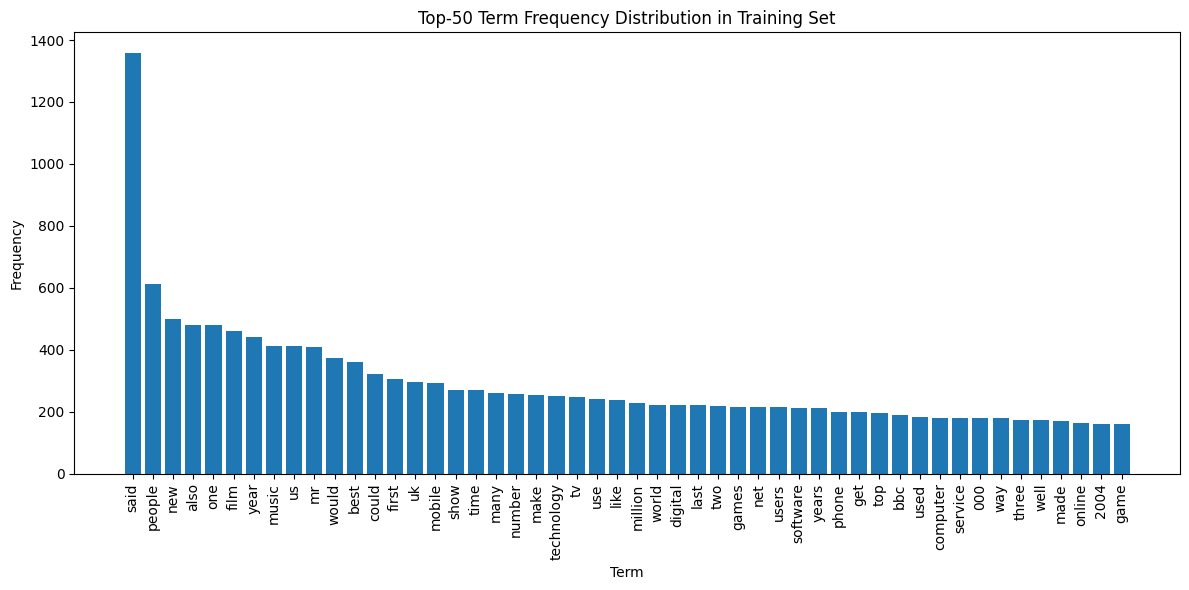

In [66]:
train_term_counts = np.asarray(X_train_counts.sum(axis=0)).ravel()

top_50_terms, top_50_frequencies = get_top_terms_and_frequencies(train_term_counts, count_feature_names, 50)

plt.figure(figsize=(12, 6))
plt.bar(top_50_terms, top_50_frequencies)
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.title("Top-50 Term Frequency Distribution in Training Set")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Task 1(b)(ii): Term frequency distribution per class

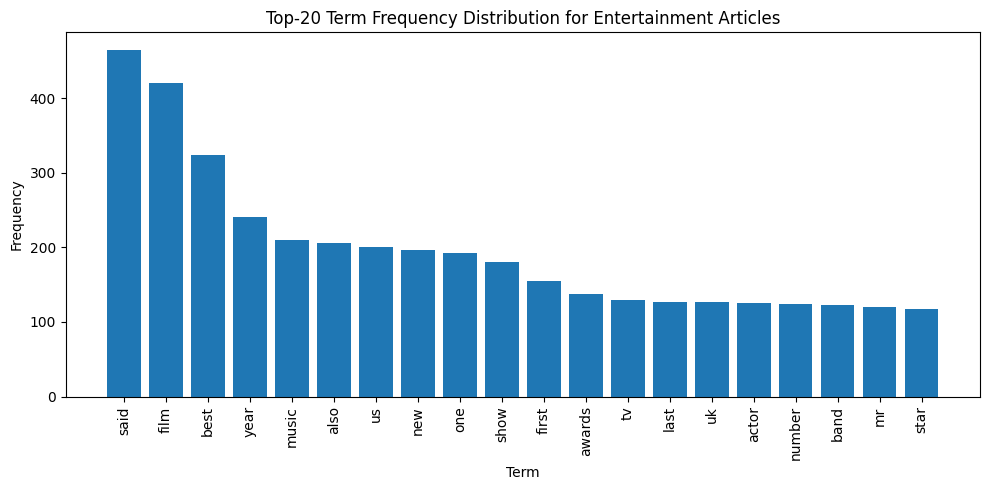

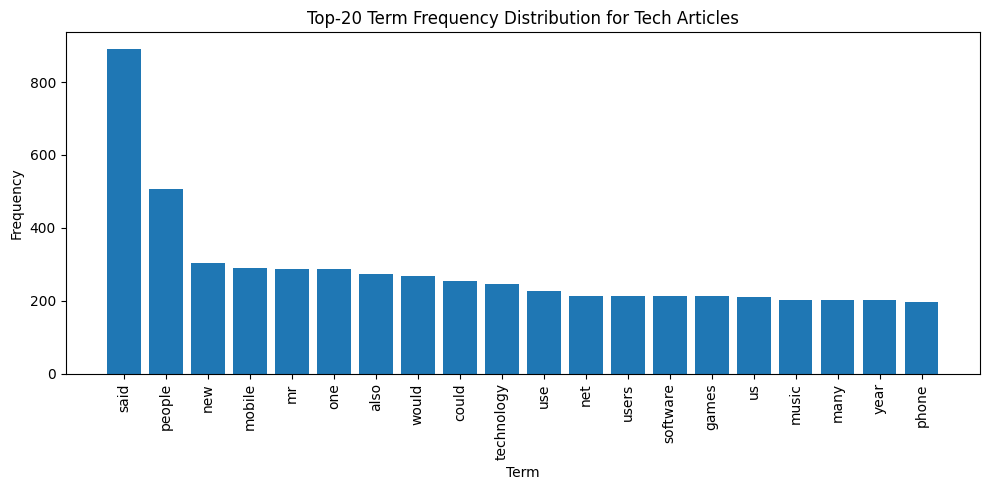

In [67]:
for category in sorted(train_df["Category"].unique()):

    # Convert the pandas boolean Series into a NumPy array so we can safely index the sparse matrix
    class_rows = (train_df["Category"] == category).to_numpy()
    class_term_counts = np.asarray(X_train_counts[class_rows].sum(axis=0)).ravel()

    top_terms, top_frequencies = get_top_terms_and_frequencies(class_term_counts, count_feature_names, 20)

    plt.figure(figsize=(10, 5))
    plt.bar(top_terms, top_frequencies)
    plt.xlabel("Term")
    plt.ylabel("Frequency")
    plt.title(f"Top-20 Term Frequency Distribution for {category.capitalize()} Articles")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Task 1(b)(iii): Class distribution for the training and testing set

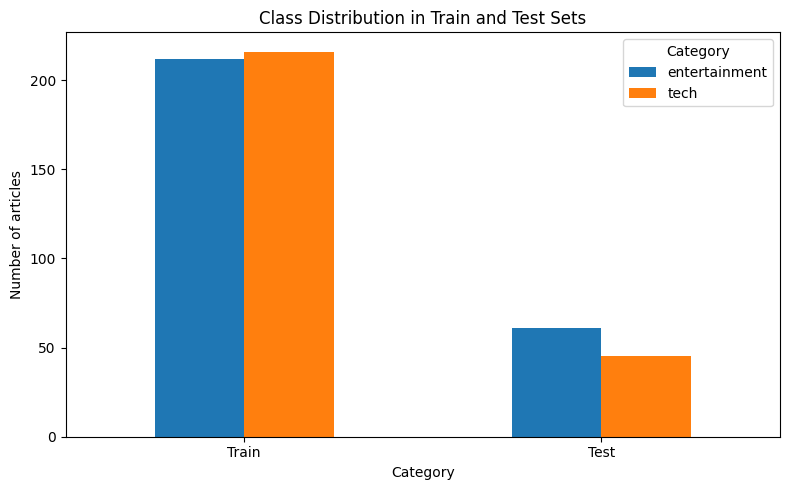

In [68]:
class_distribution_df = pd.DataFrame({
    "Train": train_df["Category"].value_counts(),
    "Test": test_df["Category"].value_counts()
}).T

class_distribution_df.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Category")
plt.ylabel("Number of articles")
plt.title("Class Distribution in Train and Test Sets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The class distribution plot compares the number of entertainment and tech articles in the train and test datasets. The training set is much larger than the test set.

Within the training set, the two classes are represented in very similar amounts. The test set has more entertainment articles than tech articles, but both classes are still represented. Overall, there is no severe class imbalance between the two classes, which makes later model evaluation more straightforward.

<a id="task-2a"></a>
## Task 2(a): Naive Bayes (THIS PROBABLY NEEDS CHANGES AFTER TASK 1, WILL DO AT END)

### Training the Naive Bayes model
Default Laplace smoothing (`alpha=1`) keeps every word probability non-zero needed for the ratio in (ii)

In [69]:
# Count features are used for Multinomial Naive Bayes because the model is based on term counts.
nb_vectorizer = CountVectorizer()
X_train_nb = nb_vectorizer.fit_transform(train_df["Article"])
X_test_nb = nb_vectorizer.transform(test_df["Article"])

# Feature names, effectively the "vocabulary"
nb_feature_names = nb_vectorizer.get_feature_names_out()

nb_model = MultinomialNB()
nb_model.fit(X_train_nb, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Task 2(a)(i): Top 20 predictive words per class

In [70]:
class_labels = nb_model.classes_
log_probabilities = nb_model.feature_log_prob_

top_n = 20

# Get the 20 words with the highest log probability within each class
top_words_by_class = {}

for class_index, class_label in enumerate(class_labels):
    top_indices = np.argsort(log_probabilities[class_index])[::-1][:top_n]
    top_words_by_class[class_label] = nb_feature_names[top_indices]

top_words_df = pd.DataFrame(top_words_by_class)
display(top_words_df)

,entertainment,tech
0,said,said
1,film,people
2,best,new
3,year,mobile
4,music,mr
5,also,one
6,us,also
7,new,would
8,one,could
9,show,technology


### Task 2(a)(ii): Top 20 discriminative words

To better understand what the Naive Bayes model learned, we compare the conditional word probabilities for the `tech` and `entertainment` classes. For each word, we calculated the ratio:

`P(word | tech) / P(word | entertainment)`

A large ratio indicates that the word is much more strongly associated with tech articles than entertainment articles, while a very small ratio indicates the opposite. To make the comparison easier to interpret, I displayed the top tech-associated words on the left and the top entertainment-associated words on the right, using the reciprocal ratio for entertainment words.

This helps identify words that are not just common overall, but actually useful for distinguishing between the two classes.

In [71]:
tech_index = np.where(class_labels == "tech")[0][0]
entertainment_index = np.where(class_labels == "entertainment")[0][0]

# Compare how strongly each word is associated with tech versus entertainment.
# A high ratio means the word is much more common in tech articles than entertainment articles.
log_ratio = log_probabilities[tech_index] - log_probabilities[entertainment_index]
ratio = np.exp(log_ratio)

top_tech_word_indices = np.argsort(log_ratio)[::-1][:20]
top_entertainment_word_indices = np.argsort(log_ratio)[:20]

# Show the most discriminative words for tech on the left, and entertainment on the right.
discriminative_words_df = pd.DataFrame({
    "tech_word": nb_feature_names[top_tech_word_indices],
    "P(word|tech) / P(word|entertainment)": ratio[top_tech_word_indices].round(1),
    "entertainment_word": nb_feature_names[top_entertainment_word_indices],
    "P(word|entertainment) / P(word|tech)": (1 / ratio[top_entertainment_word_indices]).round(1)
})

display(discriminative_words_df)

,tech_word,P(word|tech) / P(word|entertainment),entertainment_word,P(word|entertainment) / P(word|tech)
0,users,157.3,actress,124.3
1,software,156.6,singer,123.0
2,microsoft,113.4,oscar,120.2
3,mobile,106.5,stars,103.9
4,broadband,94.4,aviator,86.1
5,virus,90.0,band,84.7
6,firms,83.4,nominated,75.2
7,pc,79.8,rock,72.4
8,spam,62.2,festival,72.4
9,phones,53.1,album,67.6


### Discussion

The top 20 predictive words per class are the words with the highest estimated conditional probability under that class. These lists include some meaningful class-related terms, but they can also contain generally frequent words.

The ratio-based discriminative list is more useful for distinguishing the classes because it compares how much more likely a word is under one class than the other. 

Words with a higher value of `P(word|tech) / P(word|entertainment)` are especially associated with tech articles rather than merely being frequent overall. Therefore, the discriminative ratio list better describes the difference between the two classes.

## Task 2(b): k-Nearest Neighbors (kNN) 
In this section, we train a k-Nearest Neighbours classifier for article classification. Since the original text feature vectors are high-dimensional, we use dimensionality reduction to project the processed features into two dimensions for the decision boundary plot. This 2D plot is a visual approximation of the classifier behaviour rather than the full high-dimensional decision boundary.

### Train kNN classifier

We represent articles using count features followed by TF-IDF weighting. We then select a subset of informative features using the chi-squared statistic before training the kNN classifier. This reduces the dimensionality of the text representation, which is useful because kNN can perform poorly when there are too many sparse features.

We use \(k = 51\), cosine distance, and 200 selected features, matching the best kNN configuration found in the hyperparameter investigation. 

Cosine distance is a natural choice for text data because it compares document direction/word distribution rather than raw document length.

In [72]:
knn_pipeline = Pipeline([
    ("tfidf", TfidfTransformer()),
    ("select", SelectKBest(score_func=chi2, k=200)),
    ("knn", KNeighborsClassifier(n_neighbors=51, metric="cosine"))
])

knn_pipeline.fit(X_train_counts, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('select', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"norm norm: {'l1', 'l2'} or None, default='l2'Each output row will have unit norm, either:- 'l2': Sum of squares of vector elements is 1. The cosine similarity between two vectors is their dot product when l2 norm has been applied.- 'l1': Sum of absolute values of vector elements is 1. See :func:`~sklearn.preprocessing.normalize`.- None: No normalization.",'l2'
,"use_idf use_idf: bool, default=TrueEnable inverse-document-frequency reweighting. If False, idf(t) = 1.",True
,"smooth_idf smooth_idf: bool, default=TrueSmooth idf weights by adding one to document frequencies, as if anextra document was seen containing every term in the collectionexactly once. Prevents zero divisions.",True
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function chi...00179654F6090>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",200
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",51


We do a quick check that the kNN model trains and predicts successfully. The final model comparison is reported later in Task 3(b).

In [73]:
knn_train_pred = knn_pipeline.predict(X_train_counts)
knn_test_pred = knn_pipeline.predict(X_test_counts)

knn_train_f1 = f1_score(y_train, knn_train_pred, average="weighted")
knn_test_f1 = f1_score(y_test, knn_test_pred, average="weighted")

print("kNN training F1:", knn_train_f1)
print("kNN test F1:", knn_test_f1)

kNN training F1: 0.9742927490737173
kNN test F1: 0.9811320754716981


### Decision boundary plot

The original kNN model operates on high-dimensional text vectors, so it cannot be directly plotted. To produce a decision boundary plot, we reuse the fitted preprocessing steps from the kNN pipeline, project the processed feature vectors into two dimensions using PCA, and then train a separate kNN model on this 2D representation for visualisation.

In [74]:
def project_knn_features_to_2d(knn_pipeline, X_train_counts):
    # Use the fitted preprocessing steps, excluding the final kNN classifier
    knn_preprocessor = knn_pipeline[:-1]

    # Apply the same TF-IDF and feature selection steps used by the kNN pipeline
    X_train_selected = knn_preprocessor.transform(X_train_counts)

    # PCA requires dense input, so convert after reducing the feature space
    X_train_selected_dense = X_train_selected.toarray()

    # Project the processed feature vectors into 2D for visualisation
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_train_2d = pca.fit_transform(X_train_selected_dense)

    return X_train_2d

In [75]:
def train_knn_for_2d_plot(X_train_2d, y_train, n_neighbors=51, metric="cosine"):
    # Encode class labels as numbers so they can be used for plotting
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)

    # Train a separate kNN model on the 2D PCA representation
    knn_2d = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric
    )

    knn_2d.fit(X_train_2d, y_train_encoded)

    return knn_2d, y_train_encoded, label_encoder

In [76]:
def plot_knn_decision_boundary(knn_2d, X_train_2d, y_train_encoded, label_encoder):
    # Create a grid of points covering the 2D PCA space
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Classify every point in the grid to colour the decision regions
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    predicted_grid_labels = knn_2d.predict(grid_points)
    predicted_grid_labels = predicted_grid_labels.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    # Plot the predicted regions
    plt.contourf(xx, yy, predicted_grid_labels, alpha=0.3)

    # Plot the actual training articles in the 2D PCA space
    scatter = plt.scatter(
        X_train_2d[:, 0],
        X_train_2d[:, 1],
        c=y_train_encoded,
        edgecolor="k",
        s=35
    )

    plt.xlabel("First PCA component")
    plt.ylabel("Second PCA component")
    plt.title("kNN Decision Boundary in 2D PCA Space")

    handles = scatter.legend_elements()[0]
    labels = list(label_encoder.classes_)

    plt.legend(
        handles=handles,
        labels=labels,
        title="Category"
    )

    plt.tight_layout()
    plt.show()

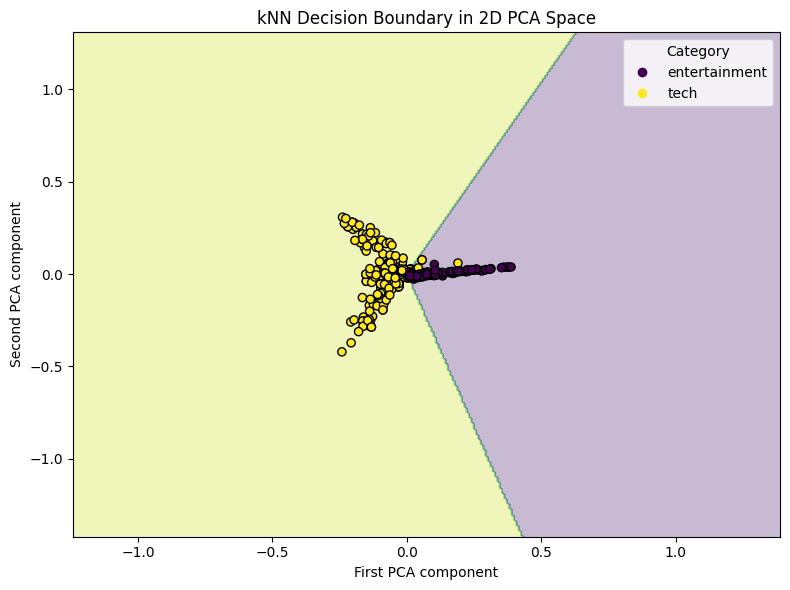

In [77]:
X_train_2d = project_knn_features_to_2d(
    knn_pipeline,
    X_train_counts
)

knn_2d, y_train_encoded, label_encoder = train_knn_for_2d_plot(
    X_train_2d,
    y_train,
    n_neighbors=51,
    metric="cosine"
)

plot_knn_decision_boundary(
    knn_2d,
    X_train_2d,
    y_train_encoded,
    label_encoder
)

The decision boundary is plotted using a 2D PCA projection of the processed text features. This is used because the original article vectors are high-dimensional and cannot be directly visualised. Compared with selecting only two individual word features, PCA gives a broader summary of the feature space by using information from many features. However, this plot should still be interpreted as a 2D visual approximation rather than the exact full-dimensional kNN decision boundary.

The value of `k` affects how smooth the kNN boundary is. In this model, `k = 51` and 200 selected features are used, matching the best kNN configuration found during cross-validation. This means each prediction is based on many neighbouring points, producing a smoother boundary. This is consistent with the plot, where the boundary separates the two main clusters without forming many small irregular regions around individual points. A smaller `k` would make the model more sensitive to local points and possible noise, which could create a more jagged boundary or small isolated regions.

The distance metric also affects the boundary because it determines which articles are considered nearest neighbours. We use cosine distance because it is well-suited to text data: it compares the direction of document vectors, which reflects word distribution, rather than being dominated by vector magnitude or document length. This means two articles with similar word usage can be treated as close even if their lengths differ.

<a id="task-2d"></a>
## Task 2(d): Artificial Neural Network

For this task, we train a single-hidden-layer neural network on the training dataset.

The network uses the following required hyperparameters:

- Initial weights uniformly drawn from the range $[0, 0.1]$
- Learning rate: $0.01$
- Number of training epochs: $100$
- Hidden units: $h \in \{2, 5, 20, 40\}$

The input layer consists of the extracted text feature vector for each article:

$$
x = [x_1, x_2, \ldots, x_n]^T
$$

The hidden layer contains $h$ hidden units:

$$
z = [z_1, z_2, \ldots, z_h]^T
$$

The output layer gives a probability distribution over the two classes:

$$
y = [y_1, y_2]^T
$$

We train the model separately for each value of $h$, then plot the final binary cross-entropy loss on the training data against the number of hidden units. Finally, we briefly discuss how changing the number of hidden units affects the model.

In [78]:
'''
hidden_units = [2, 5, 20, 40]
losses = []

# Train the model with different numbers of hidden units and record the loss
for h in hidden_units:
    model = MLPClassifier(
        hidden_layer_sizes=(h,),
        learning_rate_init=0.01,
        max_iter=100,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    losses.append(model.loss_)  # final training loss

# Plot the results
plt.plot(hidden_units, losses, marker='o')
plt.xlabel('Number of Hidden Units')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Loss vs Number of Hidden Units')
plt.show()
'''

"\nhidden_units = [2, 5, 20, 40]\nlosses = []\n\n# Train the model with different numbers of hidden units and record the loss\nfor h in hidden_units:\n    model = MLPClassifier(\n        hidden_layer_sizes=(h,),\n        learning_rate_init=0.01,\n        max_iter=100,\n        random_state=RANDOM_STATE\n    )\n    model.fit(X_train, y_train)\n    losses.append(model.loss_)  # final training loss\n\n# Plot the results\nplt.plot(hidden_units, losses, marker='o')\nplt.xlabel('Number of Hidden Units')\nplt.ylabel('Binary Cross-Entropy Loss')\nplt.title('Loss vs Number of Hidden Units')\nplt.show()\n"

### Report / Reasoning

As the number of hidden units increases, the training loss tends to decrease. This is because more hidden units give the model greater capacity to learn complex patterns in the data. However, beyond a certain point, the improvements become smaller, adding more units yields diminishing returns. Additionally, too many hidden units risks overfitting the model to the training data, which would hurt performance on unseen data.

## Task 3(a): Hyperparameter Investigation For Each Classifier with 5-Fold Cross-Validation

E.g., for SVM, the classification accuracy may be significantly affected by the kernels and associated hyperparameters. List hyperparameters for each classifier and demonstrate how these hyperparameters impact the model performance (cross-validation performance). [1 pt] 

## Desired Final Outputs from Task 3(a)

```python
best_nb_model
best_nb_params

best_knn_model
best_knn_params

best_svm_model
best_svm_params

best_ann_model
best_ann_params
```

Where each best_*_model is preferably a full pipeline.
Then task 3b) and 3c) can use and loop over:

```python
models = {
    "Naive Bayes": best_nb_model,
    "kNN": best_knn_model,
    "SVM": best_svm_model,
    "ANN": best_ann_model,
}
```

### Naive Bayes

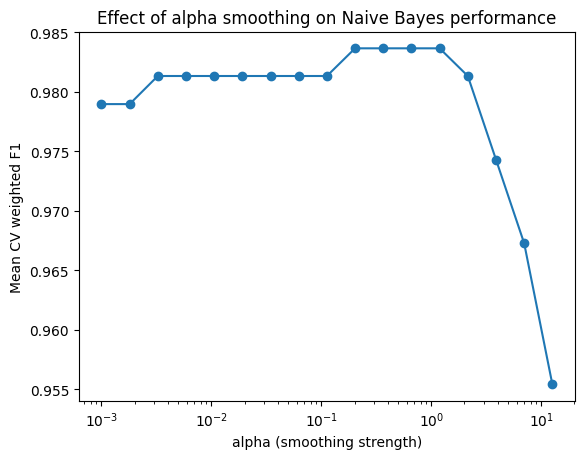

Best NB parameters: {'nb__alpha': 0.1, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': (1, 2)}
Best mean CV F1: 0.9883


In [79]:
# Pipeline wraps the vectorizer and classifier together so cross-validation doesn't leak vocabulary
nb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("nb", MultinomialNB())
])

stratified_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Investigate the effect of alpha smoothing on cross-validation performance
alpha_values = np.logspace(-3, 1.1, 17)

_, validation_scores = validation_curve(
    nb_pipeline,
    train_df["Article"],
    y_train,
    param_name="nb__alpha",
    param_range=alpha_values,
    cv=stratified_k_fold,
    scoring="f1_weighted",
    n_jobs=-1
)

plt.semilogx(alpha_values, validation_scores.mean(axis=1), "o-")
plt.xlabel("alpha (smoothing strength)")
plt.ylabel("Mean CV weighted F1")
plt.title("Effect of alpha smoothing on Naive Bayes performance")
plt.show()


# Grid search over vocab settings and alpha to find the best parameter combination
nb_param_grid = {
    "vectorizer__ngram_range": [(1, 1), (1, 2)], # tests only single words vs single words and bigrams
    "vectorizer__min_df": [1, 2, 5],             # compares all words, words in atleast 2 documents, and then atleast 5
    "nb__alpha": [0.01, 0.1, 0.5, 1.0, 2.0]
}

nb_grid = GridSearchCV(
    nb_pipeline,
    nb_param_grid,
    cv=stratified_k_fold,
    scoring="f1_weighted",
    n_jobs=-1
)

nb_grid.fit(train_df["Article"], y_train)

print("Best NB parameters:", nb_grid.best_params_)
print("Best mean CV F1:", round(nb_grid.best_score_, 4))

best_nb_model = nb_grid.best_estimator_
best_nb_params = nb_grid.best_params_

For Naive Bayes, we investigated the smoothing parameter `alpha`, along with simple vectorizer settings such as `ngram_range` and `min_df`.

The smoothing parameter controls how much probability mass is assigned to rare or unseen words. Very small `alpha` values apply little smoothing, so rare words can have overly strong influence. 

Larger `alpha` values smooth the probabilities more heavily, which can make the model less sensitive to rare words, but may also weaken useful word-class associations.

Based on 5-fold cross-validation, the best NB setting used alpha = 0.1. 

The selected vocabulary settings were min_df = 2 and ngram_range = (1, 2), suggesting that removing words appearing in only one document and including bigrams slightly improved cross-validation F1 for this split. 

However, the validation scores were close across several settings, so this improvement should be interpreted as modest rather than a large effect.

### k-Nearest Neighbours

For kNN, we investigate three key hyperparameters: the number of selected features, the number of neighbours \(k\), and the distance metric. The number of selected features controls how many text features are kept after chi-squared feature selection. The number of neighbours controls how local or smooth the classifier is. The distance metric determines how similarity between articles is measured.

In [80]:
knn_cv_pipeline = Pipeline([
    ("tfidf", TfidfTransformer()),
    ("select", SelectKBest(score_func=chi2)),
    ("knn", KNeighborsClassifier())
])

# Tune feature selection, number of neighbours, and distance metric
knn_param_grid = {
    "select__k": [100, 200, 400],
    "knn__n_neighbors": [5, 11, 21, 51],
    "knn__metric": ["cosine", "euclidean"]
}

knn_grid = GridSearchCV(
    knn_cv_pipeline,
    knn_param_grid,
    cv=stratified_k_fold,
    scoring="f1_weighted",
    n_jobs=-1
)

knn_grid.fit(X_train_counts, y_train)

print("Best kNN parameters:", knn_grid.best_params_)
print("Best mean CV F1:", knn_grid.best_score_)

Best kNN parameters: {'knn__metric': 'cosine', 'knn__n_neighbors': 51, 'select__k': 200}
Best mean CV F1: 0.9766237753518505


In [81]:
knn_cv_results_df = pd.DataFrame(knn_grid.cv_results_)

# Show the best-performing hyperparameter combinations
knn_cv_summary = knn_cv_results_df[
    [
        "param_select__k",
        "param_knn__n_neighbors",
        "param_knn__metric",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

display(knn_cv_summary.head(10))

,param_select__k,param_knn__n_neighbors,param_knn__metric,mean_test_score,std_test_score,rank_test_score
10,200,51,cosine,0.976624,0.016612,1
11,400,51,cosine,0.976604,0.024592,2
7,200,21,cosine,0.974294,0.018743,3
2,400,5,cosine,0.972016,0.021579,4
5,400,11,cosine,0.971951,0.020485,5
8,400,21,cosine,0.971951,0.020485,5
4,200,11,cosine,0.969668,0.018934,7
0,100,5,cosine,0.969664,0.017438,8
3,100,11,cosine,0.969632,0.015794,9
1,200,5,cosine,0.967344,0.020034,10


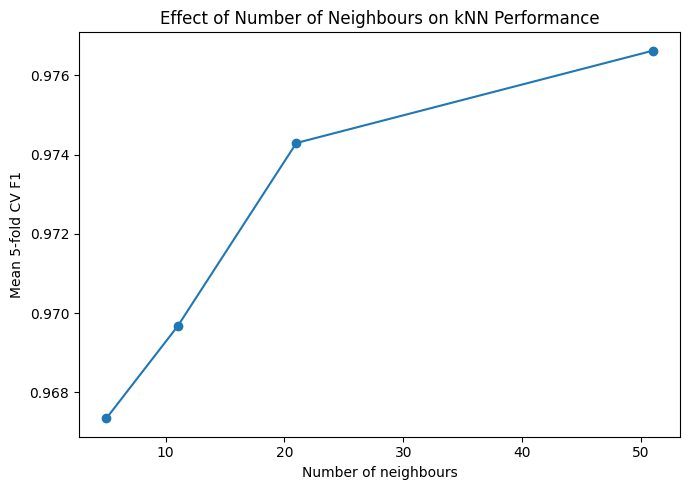

In [82]:
best_knn_metric = knn_grid.best_params_["knn__metric"]
best_select_k = knn_grid.best_params_["select__k"]

# Isolate the effect of k by keeping the other hyperparameters fixed at their best values
knn_k_effect_df = knn_cv_results_df[
    (knn_cv_results_df["param_knn__metric"] == best_knn_metric) &
    (knn_cv_results_df["param_select__k"] == best_select_k)
].copy()

knn_k_effect_df = knn_k_effect_df.sort_values("param_knn__n_neighbors")

plt.figure(figsize=(7, 5))
plt.plot(
    knn_k_effect_df["param_knn__n_neighbors"],
    knn_k_effect_df["mean_test_score"],
    marker="o"
)

plt.xlabel("Number of neighbours")
plt.ylabel("Mean 5-fold CV F1")
plt.title("Effect of Number of Neighbours on kNN Performance")
plt.tight_layout()
plt.show()

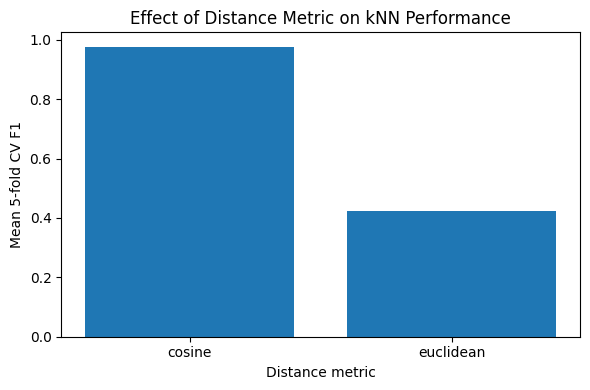

In [83]:
best_n_neighbors = knn_grid.best_params_["knn__n_neighbors"]
best_select_k = knn_grid.best_params_["select__k"]

# Isolate the effect of the distance metric by keeping k and selected features fixed
knn_metric_effect_df = knn_cv_results_df[
    (knn_cv_results_df["param_knn__n_neighbors"] == best_n_neighbors) &
    (knn_cv_results_df["param_select__k"] == best_select_k)
].copy()

knn_metric_effect_df = knn_metric_effect_df.sort_values("param_knn__metric")

plt.figure(figsize=(6, 4))
plt.bar(
    knn_metric_effect_df["param_knn__metric"],
    knn_metric_effect_df["mean_test_score"]
)

plt.xlabel("Distance metric")
plt.ylabel("Mean 5-fold CV F1")
plt.title("Effect of Distance Metric on kNN Performance")
plt.tight_layout()
plt.show()

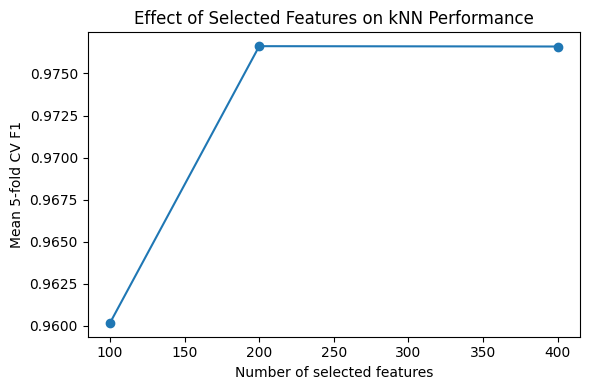

In [84]:
best_n_neighbors = knn_grid.best_params_["knn__n_neighbors"]
best_knn_metric = knn_grid.best_params_["knn__metric"]

# Isolate the effect of selected feature count by keeping k and metric fixed
knn_feature_effect_df = knn_cv_results_df[
    (knn_cv_results_df["param_knn__n_neighbors"] == best_n_neighbors) &
    (knn_cv_results_df["param_knn__metric"] == best_knn_metric)
].copy()

knn_feature_effect_df = knn_feature_effect_df.sort_values("param_select__k")

plt.figure(figsize=(6, 4))
plt.plot(
    knn_feature_effect_df["param_select__k"],
    knn_feature_effect_df["mean_test_score"],
    marker="o"
)

plt.xlabel("Number of selected features")
plt.ylabel("Mean 5-fold CV F1")
plt.title("Effect of Selected Features on kNN Performance")
plt.tight_layout()
plt.show()

The cross-validation search selected cosine distance, \(k = 51\), and 200 selected features as the best kNN configuration. 

The plot for \(k\) holds the distance metric and selected feature count fixed at their best values, so it shows the effect of changing the number of neighbours more directly. In this setting, larger \(k\) values improved mean CV F1, suggesting that smoothing over more neighbours helped generalisation.

Cosine distance performed best when the other hyperparameters were held fixed. This is reasonable for text classification because cosine distance compares the direction of TF-IDF vectors rather than their magnitude, so articles with similar word distributions can be treated as similar even if their lengths differ.

The number of selected features also matters because kNN can perform poorly in very high-dimensional sparse spaces. Feature selection keeps the most informative terms before neighbour distances are computed. In our results, 200 selected features gave the best overall cross-validation performance.

In [85]:
best_knn_model = knn_grid.best_estimator_
best_knn_params = knn_grid.best_params_

## Task 3(b): Comparison of Final Classifiers

(b) Report and compare your NB, kNN, SVM and NN classifiers with the best hyperparameter settings.
Summarize what you have observed in the classification accuracy in 𝐹1 measure on the testing dataset. [0.5 pt]

<strong>WILL DO WHEN ALL CLASSIFIERS ARE READY</strong>

## Task 3(c): Effect of training set size

Explore how the size of the training data set affects the test and train accuracy of NB, kNN, SVM and ANN classifiers with the best hyperparameter settings. 

For each value `m` in [0.1, 0.3, 0.5, 0.7, 0.9], train your classifier on the first `m` portion of the training instances (that is, `data[0:mN]`, assuming, data is dataframe with `N` training instances, as loaded from the provided file. 

Please report two plots: <br/>
(i) train accuracy, and <br/>
(ii) test accuracy 

for each such value of `m` with the x-axis referring to `m` and the y-axis referring to the classification accuracy as measured by <br/>
𝐹1 = 2(precision x recall) / (precision + recall). 

In total, there should be four curves for train accuracy and four curves for test accuracy. <br/>
Explain the general trend of the two plots in terms of training and testing accuracy if any. [2 pts]


### Naive Bayes

In [86]:
from sklearn.base import clone

training_proportions = [0.1, 0.3, 0.5, 0.7, 0.9]

def get_subset(X, end):
    # Pandas Series/DataFrames need .iloc; sparse matrices and NumPy arrays can use normal slicing
    if hasattr(X, "iloc"):
        return X.iloc[:end]
    return X[:end]


def evaluate_training_size_model(model, X_train_data, y_train, X_test_data, y_test, proportions):
    train_f1_scores = []
    test_f1_scores = []

    n = len(y_train)

    for m in proportions:
        end = int(m * n)

        X_subset = get_subset(X_train_data, end)
        y_subset = get_subset(y_train, end)

        model_clone = clone(model)
        model_clone.fit(X_subset, y_subset)

        train_pred = model_clone.predict(X_subset)
        test_pred = model_clone.predict(X_test_data)

        train_f1_scores.append(f1_score(y_subset, train_pred, average="weighted"))
        test_f1_scores.append(f1_score(y_test, test_pred, average="weighted"))

    return train_f1_scores, test_f1_scores

In [87]:
nb_train_f1, nb_test_f1_by_size = evaluate_training_size_model(
    best_nb_model,
    train_df["Article"],
    y_train,
    test_df["Article"],
    y_test,
    training_proportions
)

nb_training_size_df = pd.DataFrame({
    "m": training_proportions,
    "NB train F1": nb_train_f1,
    "NB test F1": nb_test_f1_by_size
})

display(nb_training_size_df)

,m,NB train F1,NB test F1
0,0.1,1.000000,0.971798
1,0.3,1.000000,0.971737
2,0.5,0.995328,0.981132
3,0.7,0.996656,0.981180
4,0.9,0.997403,1.000000
